## Bifurcación transcrítica en 2 Dimensiones

**Forma normal:**
$$
\begin{cases}
\dot{x} = \mu x - x^2, \\
\dot{y} = -y.
\end{cases}
$$

Las soluciones de equilibrio son
$$
x^* = 0
\quad \text{y} \quad
x^* = (\mu, 0).
$$
Pero notemos que en $\mu=0$ tenemos que solo existe el punto de equilibrio $(0,0)$

y para $\mu \neq 0$ hay 2 puntos de equilibrio

El Jacobiano del sistema es
$$
J =
\begin{pmatrix}
\mu - 2x & 0 \\
0 & -1
\end{pmatrix}.
$$

Evaluando en $(0,0)$:
$$
J_{(0,0)} =
\begin{pmatrix}
\mu & 0 \\
0 & -1
\end{pmatrix}.
$$
De donde, det $(J_{(0,0)})=-\mu$

y sus valores propios son:
$$
\lambda_1 = -1,
\qquad
\lambda_2 = \mu.
$$


- Si $\mu < 0$, $(0,0)$ es un **nodo estable**.
- Si $\mu > 0$, $(0,0)$ es un **punto silla**.

Evaluando en $(\mu,0)$:
$$
J_{(\mu,0)} =
\begin{pmatrix}
-\mu & 0 \\
0 & -1
\end{pmatrix}.
$$

Entonces:
- Si $\mu < 0$, $(\mu,0)$ es un **punto silla**.
- Si $\mu > 0$, $(\mu,0)$ es un **nodo estable**.

Por lo tanto tenemos que:

- Si $\mu>0\quad (0,0)$ es punto silla y $(\mu,0)$ es un nodo estable
- Si $\mu<0\quad (0,0)$ es un nodo estable y $(\mu,0)$ es un punto silla

De donde esto es el compórtamiento de una bifurcacion transcritica


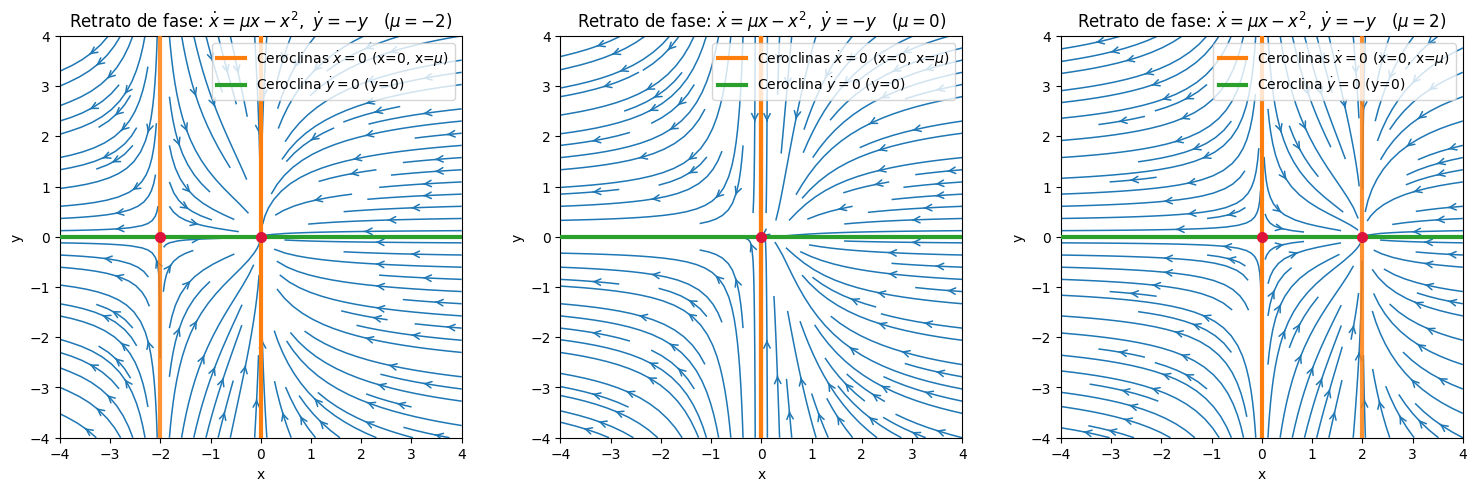

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Sistema:
# xdot = mu*x - x^2
# ydot = -y
def field(X, Y, mu):
    U = mu*X - X**2
    V = -Y
    return U, V

def plot_phase(ax, mu, Lx=4, Ly=4, dens=1.15):
    x = np.linspace(-Lx, Lx, 350)
    y = np.linspace(-Ly, Ly, 350)
    X, Y = np.meshgrid(x, y)
    U, V = field(X, Y, mu)

    # Retrato de fase
    ax.streamplot(
        x, y, U, V,
        density=dens,
        linewidth=1.1,
        arrowsize=1.15,
        arrowstyle='->',
        color='tab:blue',
        zorder=1
    )

    # Ejes
    ax.axhline(0, color='k', lw=1, zorder=0)
    ax.axvline(0, color='k', lw=1, zorder=0)

    # --- Ceroclinas ---
    # xdot=0 => x(mu - x)=0 => x=0 y x=mu (verticales)
    # ydot=0 => y=0 (horizontal)
    ax.plot([0, 0], [-Ly, Ly], color='tab:orange', lw=3, zorder=3)  # x=0

    # x=mu (si mu cae dentro de la ventana; si no, igual se dibuja fuera)
    ax.plot([mu, mu], [-Ly, Ly], color='tab:orange', lw=3, alpha=0.85, zorder=3)

    ax.plot([-Lx, Lx], [0, 0], color='tab:green', lw=3, zorder=3)   # y=0

    # Puntos de equilibrio: intersección de ceroclinas => (0,0) y (mu,0)
    eqs = [(0.0, 0.0)]
    if abs(mu) > 1e-12:
        eqs.append((float(mu), 0.0))
    for (xe, ye) in eqs:
        ax.plot(xe, ye, 'o', color='crimson', ms=7, zorder=5)

    # Leyenda (una por subplot)
    handles = [
        Line2D([0],[0], color='tab:orange', lw=3, label=r'Ceroclinas $\dot{x}=0$ (x=0, x=$\mu$)'),
        Line2D([0],[0], color='tab:green',  lw=3, label=r'Ceroclina $\dot{y}=0$ (y=0)')
    ]
    ax.legend(handles=handles, loc='upper right', frameon=True)

    ax.set_xlim(-Lx, Lx)
    ax.set_ylim(-Ly, Ly)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(rf"Retrato de fase: $\dot x=\mu x-x^2,\ \dot y=-y$   ($\mu={mu}$)")

# ---- Graficar para mu = -2, 0, 2 ----
mus = [-2, 0, 2]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

for ax, mu in zip(axes, mus):
    plot_phase(ax, mu, Lx=4, Ly=4, dens=1.15)

plt.show()


### Silla - Nodo

Consideramos el sistema
$$
\begin{cases}
\dot{x} = \mu - x^2, \\
\dot{y} = -y,
\end{cases}
\qquad \mu \in \mathbb{R}.
$$

Buscando los puntos de equilibrio, tenemos que
$$
\mu - x^2 = 0,
\qquad
-y = 0.
$$

Por lo tanto:

- Si $\mu > 0$,
  $$
  x_{1,2}^* = \pm \sqrt{\mu}, \qquad y^* = 0.
  $$

- Si $\mu < 0$, **no hay puntos de equilibrio**.

- Si $\mu = 0$,
  $$
  x^* = 0, \qquad y^* = 0.
  $$

El Jacobiano del sistema es
$$
J(x,y) =
\begin{pmatrix}
-2x & 0 \\
0 & -1
\end{pmatrix}.
$$


### Para $\mu = 0$

Evaluando en el equilibrio:
$$
J\big|_{(0,0)} =
\begin{pmatrix}
0 & 0 \\
0 & -1
\end{pmatrix}.
$$

Los autovalores son
$$
\lambda_1 = 0, \qquad \lambda_2 = -1.
$$

El análisis de estabilidad lineal **no es concluyente**.

---

### Caso $\mu > 0$

Para $x^* = \pm \sqrt{\mu}$:
$$
J\big|_{(x^*,0)} =
\begin{pmatrix}
-2x^* & 0 \\
0 & -1
\end{pmatrix}.
$$

Es decir,
$$
J\big|_{(\pm\sqrt{\mu},0)} =
\begin{pmatrix}
\mp 2\sqrt{\mu} & 0 \\
0 & -1
\end{pmatrix}.
$$

Los autovalores del Jacobiano son:

- Para $x^* = -\sqrt{\mu}$:
$$
\lambda_1 = \sqrt{\mu}, \qquad \lambda_2 = -1,
$$
por lo que el equilibrio es un **punto silla**.

- Para $x^* = \sqrt{\mu}$:
$$
\lambda_1 = -\sqrt{\mu}, \qquad \lambda_2 = -1,
$$
por lo que el equilibrio es un **nodo estable**.


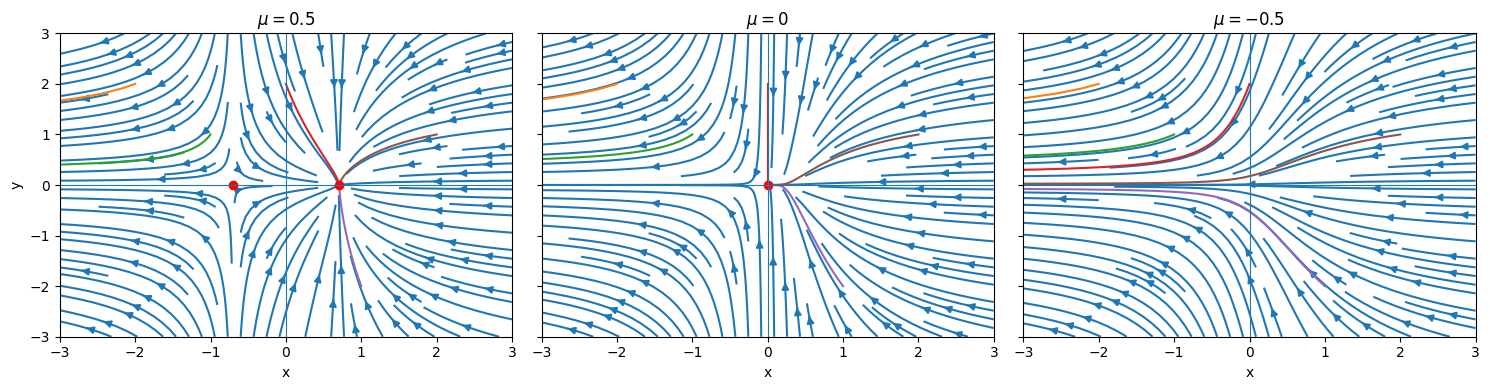

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Sistema
def sistema(t, z, mu):
    x, y = z
    dx = mu - x**2
    dy = -y
    return [dx, dy]

# Mallado del espacio fase
x = np.linspace(-3, 3, 25)
y = np.linspace(-3, 3, 25)
X, Y = np.meshgrid(x, y)

mus = [0.5, 0, -0.5]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, mu in zip(axes, mus):

    U = mu - X**2
    V = -Y

    # Campo de direcciones
    ax.streamplot(X, Y, U, V, density=1.2)

    # Trayectorias
    condiciones_iniciales = [
        [-2, 2],
        [-1, 1],
        [0, 2],
        [1, -2],
        [2, 1]
    ]

    for z0 in condiciones_iniciales:
        sol = solve_ivp(
            sistema,
            [0, 10],
            z0,
            args=(mu,),
            max_step=0.05
        )
        ax.plot(sol.y[0], sol.y[1])

    # Equilibrios en x (si existen)
    if mu > 0:
        x_eq = np.sqrt(mu)
        ax.plot([x_eq, -x_eq], [0, 0], 'ro')
    elif mu == 0:
        ax.plot(0, 0, 'ro')

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.set_title(rf"$\mu = {mu}$")
    ax.set_xlabel("x")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

axes[0].set_ylabel("y")

plt.tight_layout()
plt.show()


### Ejemplo

Consideramos el sistema
$$
\begin{cases}
\dot{x} = -a x + y, \\
\dot{y} = \dfrac{x^2}{1 + x^2} - b y,
\end{cases}
$$
con
$$
a,b > 0.
$$

Buscamos primero las ceroclinas del sistema.

- Ceroclina $\dot{x} = 0$:
$$
-a x + y = 0
\quad \Longrightarrow \quad
y = a x.
$$

- Ceroclina $\dot{y} = 0$:
$$
\dfrac{x^2}{1 + x^2} - b y = 0
\quad \Longrightarrow \quad
y = \frac{1}{b}\,\frac{x^2}{1 + x^2}.
$$

De la intersección de las ceroclinas se obtiene:

$$
a x = \frac{1}{b}\,\frac{x^2}{1 + x^2}.
$$

Para analizar la forma de la segunda ceroclina, derivamos:

$$
y = \frac{1}{b}\,\frac{x^2}{1 + x^2}.
$$

Entonces,

$$
y' = \frac{1}{b}\,
\frac{2x(1 + x^2) - 2x(x^2)}{(1 + x^2)^2}
= \frac{1}{b}\frac{2x}{(1 + x^2)^2}.
$$

En el punto de intersección de las ceroclinas, las pendientes deben coincidir.

Así,
$$
a = y' = \frac{1}{b}\,\frac{2x}{(1 + x^2)^2}.
$$

por lo que, tenemos el sistema

$$
\begin{cases}\displaystyle
a x = \frac{1}{b}\frac{x^2}{1 + x^2} \\
a =\displaystyle \frac{1}{b}\,\frac{2x}{(1 + x^2)^2}
\end{cases}
$$

obtenemos:
$$
a x = \frac{1}{b}\frac{2 x^2}{(1 + x^2)^2}=\frac{2}{1 + x^2}\frac{1}{b}\frac{x^2}{1 + x^2} =\frac{2 a x}{1 + x^2}.
$$

Es decir:

$$ax = \frac{2 a x}{1 + x^2}$$

Si $x \neq 0$, entonces
$$
1 = \frac{2}{1 + x^2},
$$
de donde
$$
x^2 + 1 = 2
\quad \Longrightarrow \quad
x^2 = 1
\quad \Longrightarrow \quad
x = \pm 1.
$$

Para $x = 1$ se tiene
$$
y = a,
$$
y en el punto
$$
(1, a)
$$
ocurre la **bifurcación**.

Además, como
$$
a = \frac{1}{b}\,\frac{2x}{(1 + x^2)^2},
$$
al evaluar en $x = 1$ se obtiene
$$
a = \frac{1}{b}\,\frac{2}{4}
= \frac{1}{2b}.
$$

Por lo tanto,
$$
a_{crit} = \frac{1}{2b}
\qquad \Longleftrightarrow \qquad
b_{crit}= \frac{1}{2a}.
$$

Ahora, Expandiendo por Taylor la función
$$
f(x) = \frac{x^2}{1 + x^2},
$$
alrededor de $x = 1$, obtenemos:

$$
f(x)
= \frac{1}{2}
+ \frac{1}{2}(x-1)
- \frac{1}{4}(x-1)^2
+ \mathcal{O}\!\big((x-1)^3\big).
$$

Por lo tanto, el sistema queda aproximado por

$$
\dot{x} = -a x + y,
$$

$$
\dot{y} \approx
\frac{1}{2}
+ \frac{1}{2}(x-1)
- \frac{1}{4}(x-1)^2
- b y.
$$

---

### Nuevamente, las ceroclinas

Las ceroclinas del sistema aproximado son:

- Ceroclina $\dot{x} = 0$:
$$
y = a x.
$$

- Ceroclina $\dot{y} = 0$:
$$
\frac{1}{2}
+ \frac{1}{2}(x-1)
- \frac{1}{4}(x-1)^2
- b y = 0.
$$

Sustituyendo $y = a x$ se obtiene:

$$
\frac{1}{2}
+ \frac{1}{2}(x-1)
- \frac{1}{4}(x-1)^2
- b a x = 0.
$$

Equivalentemente,

$$
-\frac{1}{4}x^2
+ x(1 - b a)
- \frac{1}{4}
= 0.
$$

Partimos de la ecuación cuadrática

$$
x^2 - 4(1 - b a)x + 1 = 0.
$$

Sus soluciones están dadas por

$$
x^*
= \frac{4(1 - b a) \pm \sqrt{16(1 - b a)^2 - 4}}{2}.
$$

Para que ocurra una **bifurcación**, el discriminante debe anularse:

$$
16(1 - b a)^2 - 4 = 0.
$$

Entonces,

$$
16(1 - b a)^2 = 4
\quad \Longrightarrow \quad
(1 - b a)^2 = \frac{1}{4}.
$$

De aquí se obtiene

$$
1 - b a = \pm \frac{1}{2}.
$$

Por lo tanto,

- Si
$$
1 - b a = \frac{1}{2},
$$
entonces
$$
b a = \frac{1}{2}.
$$

- Si
$$
1 - b a = -\frac{1}{2},
$$
entonces
$$
b a = \frac{3}{2}.
$$

En particular, el valor crítico donde ocurre la bifurcación es

$$
b a = \frac{1}{2}.
$$


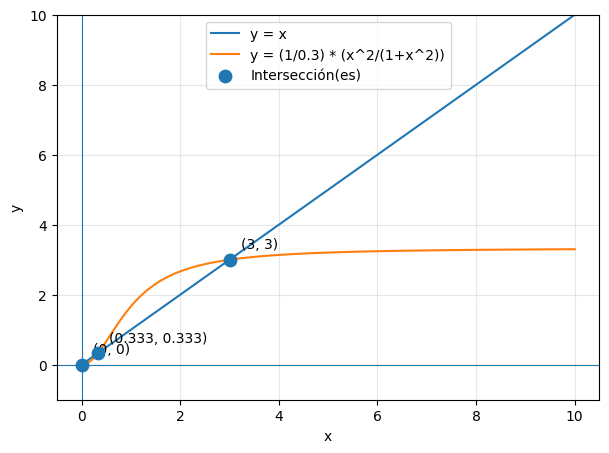

In [18]:
import numpy as np
import matplotlib.pyplot as plt

b = 0.3
x = np.linspace(0, 10, 2000)

y_linea = x
y_func  = (1/b) * (x**2 / (1 + x**2))

# Intersecciones: resolver x = (1/b) * x^2/(1+x^2)
# => x(1+x^2) = (1/b)x^2 => x^3 - (1/b)x^2 + x = 0
coef = [1, -(1/b), 1, 0]          # x^3 - (1/b)x^2 + x + 0
roots = np.roots(coef)

# quedarnos solo con raíces reales (parte imaginaria ~ 0)
x_int = roots[np.isclose(roots.imag, 0, atol=1e-10)].real
y_int = x_int  # porque en la intersección y=x

plt.figure(figsize=(7, 5))
plt.plot(x, y_linea, label='y = x')
plt.plot(x, y_func,  label=rf'y = (1/{b}) * (x^2/(1+x^2))')

# marcar intersecciones
plt.scatter(x_int, y_int, s=80, zorder=5, label='Intersección(es)')
for xi, yi in zip(x_int, y_int):
    plt.annotate(f"({xi:.3g}, {yi:.3g})", (xi, yi), textcoords="offset points", xytext=(8,8))

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(-1, 10)  # opcional
plt.show()


## Bifurcación de tridente supercrítica

Consideremos el sistema
$$
\begin{cases}
\dot x = \mu x - x^3, \\
\dot y = -y,
\end{cases}
\qquad \mu \in \mathbb{R}.
$$

Los puntos de equilibrio se obtienen de
$$
\mu x - x^3 = 0, \qquad y = 0,
$$
es decir,
$$
x^* = 0 \quad \text{y} \quad x^* = \pm\sqrt{\mu} \;\; \text{(si } \mu \ge 0\text{)}.
$$

Por lo tanto:
- Si $\mu \leq 0$, el único equilibrio es $(0,0)$
- Si $\mu > 0$, existen tres equilibrios:
$$
(0,0), \; (\sqrt{\mu},0), \; (-\sqrt{\mu},0)
$$

El Jacobiano del sistema es
$$
J(x,y) =
\begin{pmatrix}
\mu - 3x^2 & 0 \\
0 & -1
\end{pmatrix}.
$$

En el origen:
$$
J(0,0) =
\begin{pmatrix}
\mu & 0 \\
0 & -1
\end{pmatrix}.
$$

Los equilibrios $(\pm\sqrt{\mu},0)$ (cuando $\mu>0$) satisfacen
$$
J(\pm\sqrt{\mu},0) =
\begin{pmatrix}
-2\mu & 0 \\
0 & -1
\end{pmatrix},
$$
y son nodos estables.

Esto describe una **bifurcación de tridente supercrítica**.


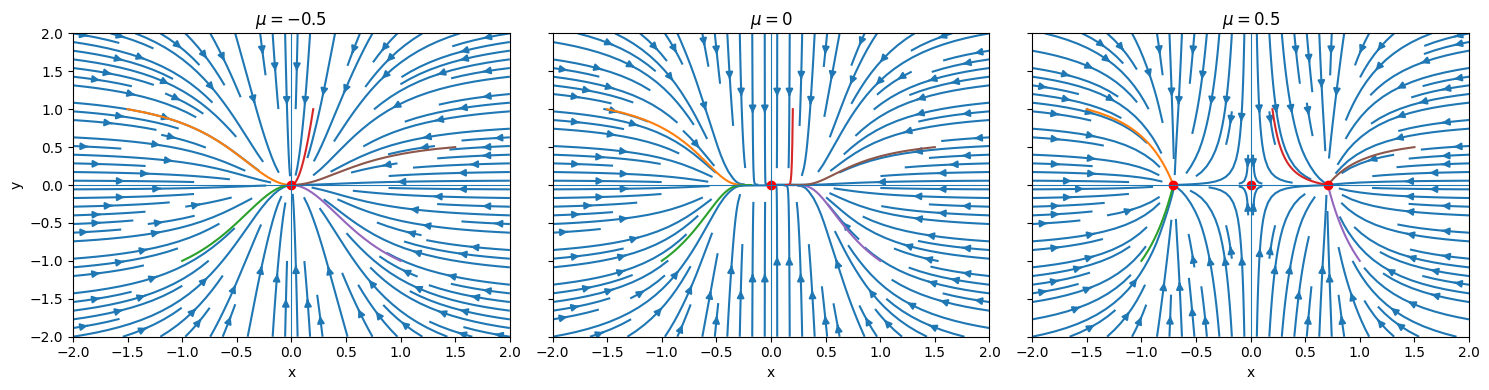

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Sistema
def sistema(t, z, mu):
    x, y = z
    dx = mu*x - x**3
    dy = -y
    return [dx, dy]

# Mallado del espacio fase
x = np.linspace(-2, 2, 25)
y = np.linspace(-2, 2, 25)
X, Y = np.meshgrid(x, y)

mus = [-0.5, 0, 0.5]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, mu in zip(axes, mus):

    U = mu*X - X**3
    V = -Y

    # Campo de direcciones
    ax.streamplot(X, Y, U, V, density=1.2)

    # Trayectorias
    condiciones_iniciales = [
        [-1.5, 1],
        [-1, -1],
        [0.2, 1],
        [1, -1],
        [1.5, 0.5]
    ]

    for z0 in condiciones_iniciales:
        sol = solve_ivp(
            sistema,
            [0, 15],
            z0,
            args=(mu,),
            max_step=0.05
        )
        ax.plot(sol.y[0], sol.y[1])

    # Puntos de equilibrio
    ax.plot(0, 0, 'ro')
    if mu > 0:
        ax.plot([np.sqrt(mu), -np.sqrt(mu)], [0, 0], 'ro')

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.set_title(rf"$\mu = {mu}$")
    ax.set_xlabel("x")
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

axes[0].set_ylabel("y")

plt.tight_layout()
plt.show()


## Bifurcación de tridente subcrítica

Consideremos el sistema
$$
\begin{cases}
\dot x = \mu x + x^3, \\
\dot y = -y,
\end{cases}
\qquad \mu \in \mathbb{R}.
$$

Los puntos de equilibrio se obtienen de
$$
\mu x + x^3 = 0, \qquad y = 0,
$$
es decir,
$$
x^* = 0 \quad \text{y} \quad x^* = \pm\sqrt{-\mu} \;\; \text{si } \mu \le 0.
$$

Por lo tanto:
- Si $\mu \geq 0$, el único equilibrio es $(0,0)$
- Si $\mu < 0$, existen tres equilibrios:
$$
(0,0), \; (\sqrt{-\mu},0), \; (-\sqrt{-\mu},0).
$$

El Jacobiano del sistema es
$$
J(x,y) =
\begin{pmatrix}
\mu + 3x^2 & 0 \\
0 & -1
\end{pmatrix}.
$$

En el origen:
$$
J(0,0) =
\begin{pmatrix}
\mu & 0 \\
0 & -1
\end{pmatrix}.
$$

Los equilibrios $(\pm\sqrt{-\mu},0)$ (cuando $\mu<0$) satisfacen
$$
J(\pm\sqrt{-\mu},0) =
\begin{pmatrix}
-2\mu & 0 \\
0 & -1
\end{pmatrix},
$$
y son puntos silla.

En el punto de bifurcación $\mu=0$, dos puntos silla colisionan con el equilibrio central,
lo que caracteriza una **bifurcación de tridente subcrítica**.


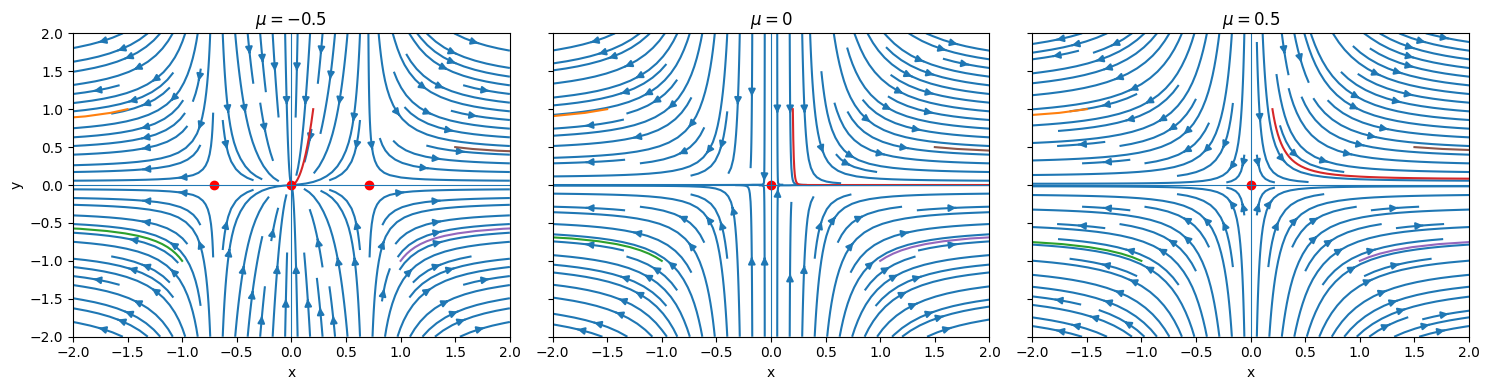

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Sistema
def sistema(t, z, mu):
    x, y = z
    dx = mu*x + x**3
    dy = -y
    return [dx, dy]

# Mallado del espacio fase
x = np.linspace(-2, 2, 25)
y = np.linspace(-2, 2, 25)
X, Y = np.meshgrid(x, y)

mus = [-0.5, 0, 0.5]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, mu in zip(axes, mus):

    U = mu*X + X**3
    V = -Y

    # Campo de direcciones
    ax.streamplot(X, Y, U, V, density=1.2)

    # Trayectorias
    condiciones_iniciales = [
        [-1.5, 1],
        [-1, -1],
        [0.2, 1],
        [1, -1],
        [1.5, 0.5]
    ]

    for z0 in condiciones_iniciales:
        sol = solve_ivp(
            sistema,
            [0, 15],
            z0,
            args=(mu,),
            max_step=0.05
        )
        ax.plot(sol.y[0], sol.y[1])

    # Puntos de equilibrio
    ax.plot(0, 0, 'ro')
    if mu < 0:
        ax.plot([np.sqrt(-mu), -np.sqrt(-mu)], [0, 0], 'ro')

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.set_title(rf"$\mu = {mu}$")
    ax.set_xlabel("x")
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

axes[0].set_ylabel("y")

plt.tight_layout()
plt.show()


### Ejemplo

Consideremos el sistema
$$
\begin{cases}
\dot x = \mu x + y + \sin x, \\
\dot y = x - y.
\end{cases}
$$

Como es una ecuación impar, hay simetría.

Buscamos los puntos de equilibrio resolviendo:
$$
\begin{cases}
x - y = 0, \\
\mu x + y + \sin x = 0.
\end{cases}
$$

De la primera ecuación se obtiene:
$$
y = x.
$$

Sustituyendo en la segunda:
$$
\mu x + x + \sin x = 0.
$$

En particular, \(x=0\) es solución, por lo que
$$
(x^*, y^*) = (0,0)
$$
es un punto de equilibrio.

El Jacobiano del sistema es:
$$
J(x,y) =
\begin{pmatrix}
\mu + \cos x & 1 \\
1 & -1
\end{pmatrix}.
$$

Evaluado en el origen:
$$
J(0,0) =
\begin{pmatrix}
\mu + 1 & 1 \\
1 & -1
\end{pmatrix}.
$$

Su determinante y traza son:
$$
\det J = -\mu - 2, \qquad \operatorname{tr} J = \mu
$$

La estabilidad del equilibrio depende del valor del parámetro $\mu$


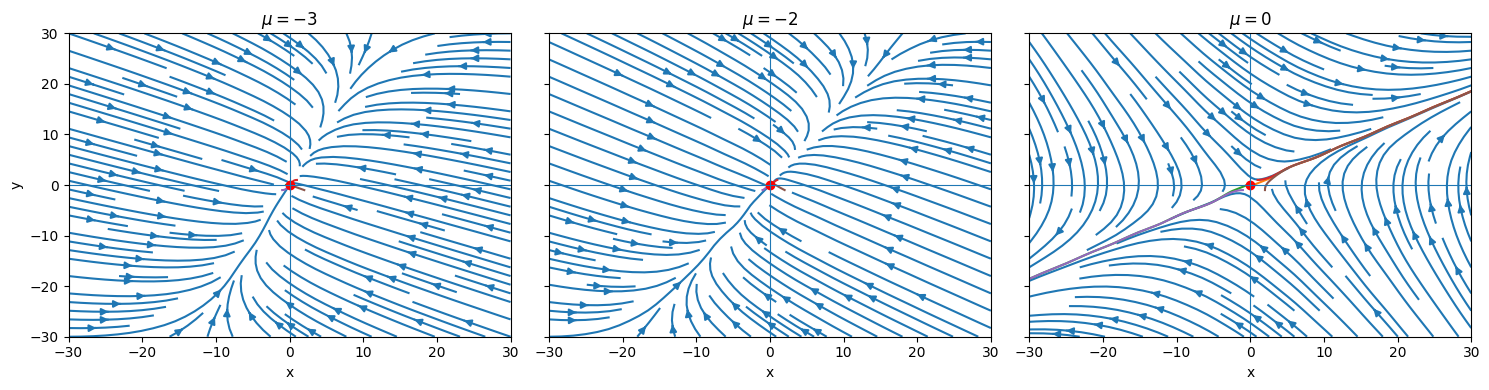

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Sistema
def sistema(t, z, mu):
    x, y = z
    dx = mu*x + y + np.sin(x)
    dy = x - y
    return [dx, dy]

# Mallado del espacio fase
x = np.linspace(-30, 30, 25)
y = np.linspace(-30, 30, 25)
X, Y = np.meshgrid(x, y)

mus = [-3, -2, 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, mu in zip(axes, mus):

    U = mu*X + Y + np.sin(X)
    V = X - Y

    # Campo de direcciones
    ax.streamplot(X, Y, U, V, density=1.2)

    # Trayectorias
    condiciones_iniciales = [
        [0.5, 0], [-0.5, 0],
        [1, 1], [-1, -1],
        [2, -1]
    ]

    for z0 in condiciones_iniciales:
        sol = solve_ivp(
            sistema,
            [0, 30],
            z0,
            args=(mu,),
            max_step=0.05
        )
        ax.plot(sol.y[0], sol.y[1])

    # Punto de equilibrio
    ax.plot(0, 0, 'ro')

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.set_title(rf"$\mu = {mu}$")
    ax.set_xlim(-30, 30)
    ax.set_ylim(-30, 30)
    ax.set_xlabel("x")

axes[0].set_ylabel("y")

plt.tight_layout()
plt.show()
